Model Trained

Evaluation Metrics:
MAE: 332.44772454472246
RMSE: 414.03114430309074


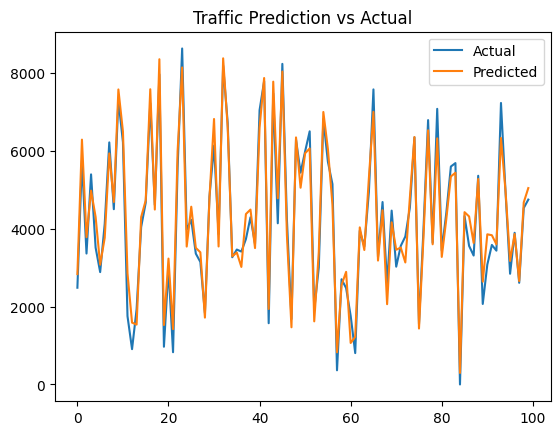


===== TRAFFIC SYSTEM OUTPUT =====
Predicted Volume: 2837.6221588119993
Congestion Level: Medium
Signal Decision: Maintain Normal Timing
Anomaly Status: Normal

===== MULTIPLE TEST CASES =====

Data Point 1
Predicted: 2837.6221588119993
Congestion: Medium
Signal: Maintain Normal Timing
Anomaly: Normal

Data Point 2
Predicted: 6294.541115680249
Congestion: High
Signal: Increase Green Time by 30%
Anomaly: Normal

Data Point 3
Predicted: 3786.166279203702
Congestion: Medium
Signal: Maintain Normal Timing
Anomaly: Normal

Data Point 4
Predicted: 4983.863617594597
Congestion: High
Signal: Increase Green Time by 30%
Anomaly: Normal

Data Point 5
Predicted: 4308.156451830241
Congestion: High
Signal: Increase Green Time by 30%
Anomaly: Normal


In [3]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


# =========================
# LOAD DATASET
# =========================
df = pd.read_csv("METRO_INTERSTATE(2).csv")

df['date_time'] = pd.to_datetime(df['date_time'])


# =========================
# FEATURE ENGINEERING
# =========================
df['hour_sin'] = np.sin(2 * np.pi * df['date_time'].dt.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['date_time'].dt.hour / 24)

df['day'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month

df['is_weekend'] = df['day'].apply(lambda x: 1 if x >= 5 else 0)

# Encode weather
df['weather_main'] = df['weather_main'].astype('category').cat.codes

df = df.dropna()


# =========================
# FEATURES & TARGET
# =========================
features = [
    'hour_sin','hour_cos',
    'day','month','is_weekend',
    'temp','rain_1h','snow_1h','clouds_all',
    'weather_main'
]

X = df[features]
y = df['traffic_volume']


# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================
# MODEL TRAINING
# =========================
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

print("Model Trained")


# =========================
# EVALUATION
# =========================
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("\nEvaluation Metrics:")
print("MAE:", mae)
print("RMSE:", rmse)


# =========================
# VISUALIZATION
# =========================
plt.figure()
plt.plot(y_test.values[:100], label='Actual')
plt.plot(pred[:100], label='Predicted')
plt.legend()
plt.title("Traffic Prediction vs Actual")
plt.show()


# =========================
# ANOMALY DETECTION
# =========================
mean_traffic = y_train.mean()
std_traffic = y_train.std()

def detect_anomaly(volume):
    if volume > mean_traffic + 2 * std_traffic:
        return "High Traffic Anomaly (Possible Accident/Event)"
    elif volume < mean_traffic - 2 * std_traffic:
        return "Low Traffic Anomaly (Unusual Drop)"
    else:
        return "Normal"


# =========================
# TRAFFIC CONTROL SYSTEM
# =========================
def congestion_level(volume):
    if volume < 2000:
        return "Low"
    elif volume < 4000:
        return "Medium"
    else:
        return "High"

def signal_control(volume):
    if volume > 4000:
        return "Increase Green Time by 30%"
    elif volume < 2000:
        return "Reduce Green Time by 20%"
    else:
        return "Maintain Normal Timing"


# =========================
# DEMO OUTPUT
# =========================
sample = X_test.iloc[0]

predicted = model.predict(sample.to_frame().T)[0]

print("\n===== TRAFFIC SYSTEM OUTPUT =====")
print("Predicted Volume:", predicted)
print("Congestion Level:", congestion_level(predicted))
print("Signal Decision:", signal_control(predicted))
print("Anomaly Status:", detect_anomaly(predicted))


# =========================
# MULTIPLE TEST OUTPUTS
# =========================
print("\n===== MULTIPLE TEST CASES =====")

for i in range(5):
    val = pred[i]
    print(f"\nData Point {i+1}")
    print("Predicted:", val)
    print("Congestion:", congestion_level(val))
    print("Signal:", signal_control(val))
    print("Anomaly:", detect_anomaly(val))

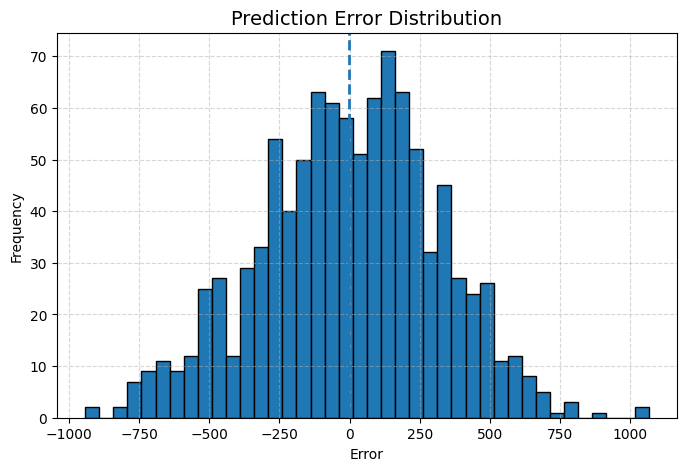

In [ ]:
# ERROR PREDICTION GRAPH
# Helps evaluate model accuracy and bias
errors = y_test - pred

plt.figure(figsize=(8,5))
plt.hist(errors, bins=40, edgecolor='black')

plt.axvline(errors.mean(), linestyle='dashed', linewidth=2)

plt.title("Prediction Error Distribution", fontsize=14)
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

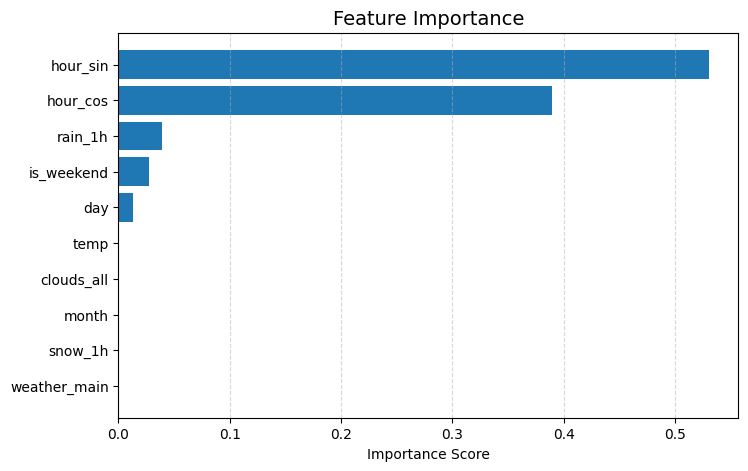

In [ ]:
# FEATURE IMPORTANCE
# Identifies key factors influencing congestion

importances = model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8,5))
plt.barh(imp_df["Feature"], imp_df["Importance"])

plt.title("Feature Importance", fontsize=14)
plt.xlabel("Importance Score")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

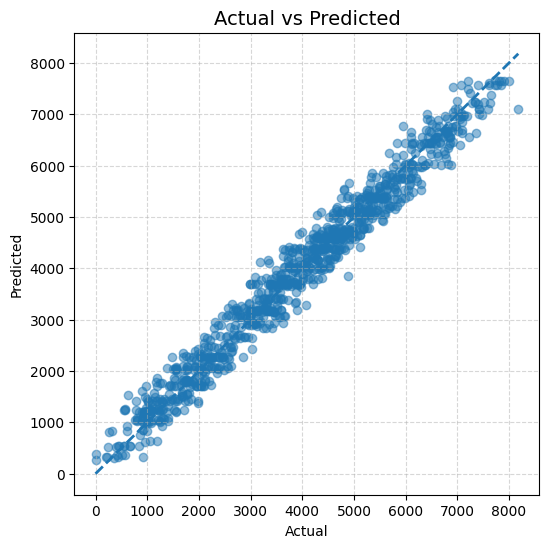

In [ ]:
# ACTUAL vs PREDICTED SCATTER
# Shows correlation between actual and predicted values
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.5)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='dashed', linewidth=2)

plt.title("Actual vs Predicted", fontsize=14)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

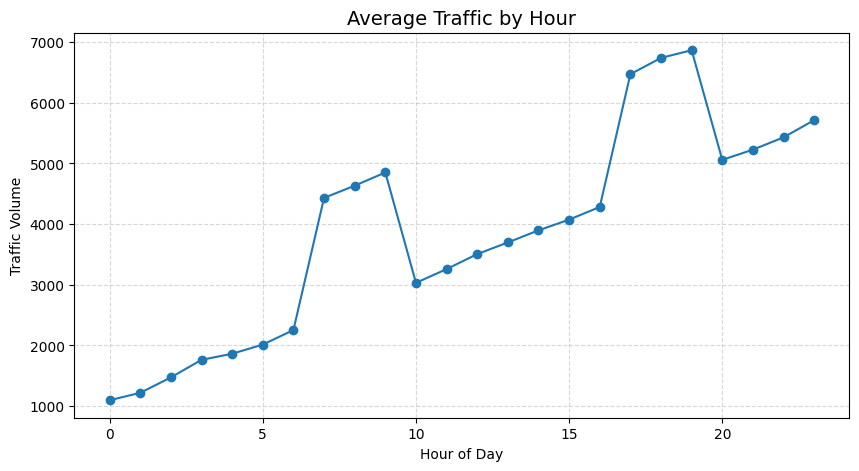

In [ ]:
# TRAFFIC BY HOUR
# Demonstrates peak traffic patterns

df['hour'] = df['date_time'].dt.hour

hourly = df.groupby('hour')['traffic_volume'].mean()

plt.figure(figsize=(10,5))
hourly.plot(marker='o')

plt.title("Average Traffic by Hour", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Traffic Volume")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

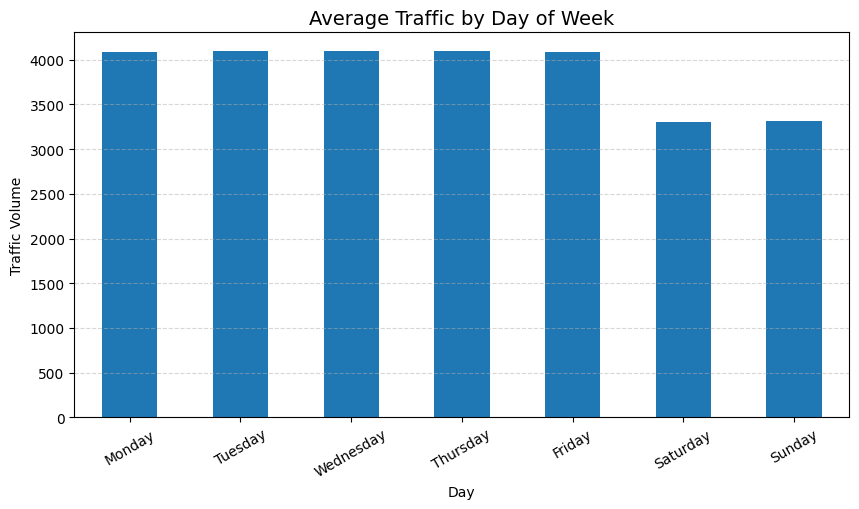

In [ ]:
# TRAFFIC DISTRIBUTION BY WEEKDAY
# Shows how traffic varies across days (very realistic insight)

df['weekday'] = df['date_time'].dt.day_name()

weekday_avg = df.groupby('weekday')['traffic_volume'].mean()

# Reorder properly
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_avg = weekday_avg.reindex(order)

plt.figure(figsize=(10,5))
weekday_avg.plot(kind='bar')

plt.title("Average Traffic by Day of Week", fontsize=14)
plt.xlabel("Day")
plt.ylabel("Traffic Volume")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

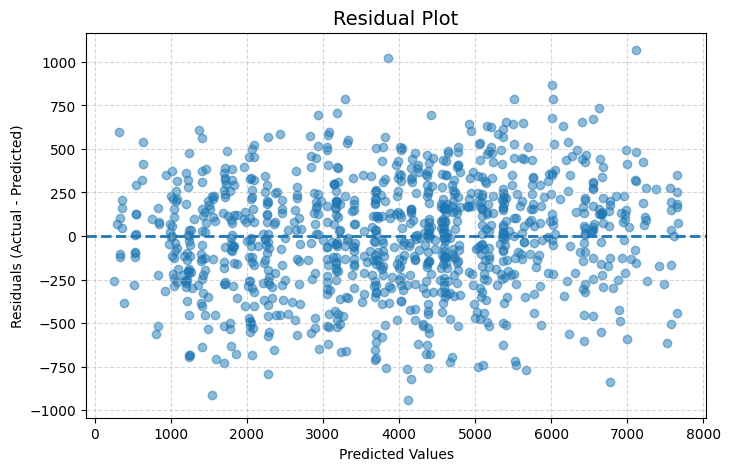

In [ ]:
# RESIDUAL PLOT
# Shows model errors vs predictions

plt.figure(figsize=(8,5))
plt.scatter(pred, y_test - pred, alpha=0.5)

plt.axhline(0, linestyle='dashed', linewidth=2)

plt.title("Residual Plot", fontsize=14)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()